In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

In [8]:
pkl_path = Path("results/admm_runs_rl/admm_results_2026-01-11_21-02-28.pkl")  # adjust to your file
with pkl_path.open("rb") as f:
    data = pickle.load(f)


df_singles = pd.read_csv("results/admm_runs_rl/results_nn_pyomo_single.csv")


In [9]:
df_singles

,regularization,times_elapsed,mse_coll_ode,mse_coll_ode_test
0,1,145.009997,0.092977,0.100134
1,1,133.665107,0.021154,0.355737
2,1,156.564767,0.091836,2.695814
3,1,150.457997,0.035014,0.377103
4,1,130.863472,0.130103,0.068344
5,1,146.230266,0.052208,0.158861
6,1,146.828048,0.003937,6.096047
7,1,152.109184,0.114982,0.824942
8,1,146.281616,0.039454,0.302092
9,1,145.532691,0.155920,1.027970


In [4]:
df = pd.DataFrame(data)
df.head()

,primal_residual,mse_diffrax,iter,time_elapsed,seed,mse_test_diffrax,mse_collocation_train,mse_collocation_test
0,"[39.7558266922021, 39.75582669172841, 78.17277...","[3.2794590776616297, 3.2794590777503996, 3.926...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22.463560342788696, 23.189019680023193, 44.70...",7458651,"[3.082901244219896, 3.0829012441935357, 3.5606...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
1,"[46.315620649872734, 46.315620647445776, 90.29...","[212.26145107951547, 212.82083220627175, 29.59...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[22.857406616210938, 23.587087631225586, 48.04...",1241253,"[2957.0863143357906, 2957.086296609875, 1262.1...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
2,"[38.52717132632789, 38.52717132242447, 74.8303...","[5.494156407118792, 5.494156449008841, 31.4644...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[20.810786485671997, 21.648167610168457, 33.75...",3798560,"[4.950972800866428, 4.950972767886427, 20.7525...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,"[43.064460879559675, 43.06446081504591, 86.386...","[871.9714982474848, 871.9705064059796, 1138.71...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[19.62995934486389, 20.514219284057617, 81.707...",7752020,"[1127.6547696846699, 1127.6539037787506, 1255....","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
4,"[41.04169266216962, 41.0416926621712, 79.70746...","[10.548258265683893, 10.548258265694537, 260.2...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[20.850682973861694, 21.701992511749268, 34.22...",2973620,"[12.359826856862702, 12.359826856875715, 178.4...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."


In [5]:
list_cols = [
    "primal_residual",
    "mse_diffrax",
    "iter",
    "time_elapsed",
    "mse_test_diffrax",
    "mse_collocation_train",
    "mse_collocation_test",
]

df_long = (
    df
    .assign(**{c: df[c].apply(list) for c in list_cols})  # in case some are arrays
    .explode(list_cols, ignore_index=True)
)

# seed is automatically duplicated by explode


In [6]:
df_long.groupby("seed").last()

,primal_residual,mse_diffrax,iter,time_elapsed,mse_test_diffrax,mse_collocation_train,mse_collocation_test
seed,,,,,,,
723276,0.151819,0.188816,19,83.415001,0.049429,None,None
1118084,0.173746,0.038262,19,80.133777,0.043103,None,None
1241253,0.151269,0.066513,19,78.022736,0.044975,None,None
1435516,0.147476,0.084489,19,74.102715,0.00964,None,None
1783026,0.181033,0.49748,19,88.292688,0.123017,None,None
2104936,0.335692,0.588047,19,108.97581,0.018754,None,None
2540198,0.169532,0.19684,19,67.324593,0.096799,None,None
2605645,0.17407,0.029479,19,67.592188,0.062715,None,None
2973620,0.170081,0.142937,19,63.86695,0.684373,None,None


In [19]:
df_singles["time_elapsed"] = df_singles["time_elapsed"] - 50

In [15]:
df_singles = df_singles.rename(columns={"times_elapsed": "time_elapsed", "mse_coll_ode": "mse_diffrax"})

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:702: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


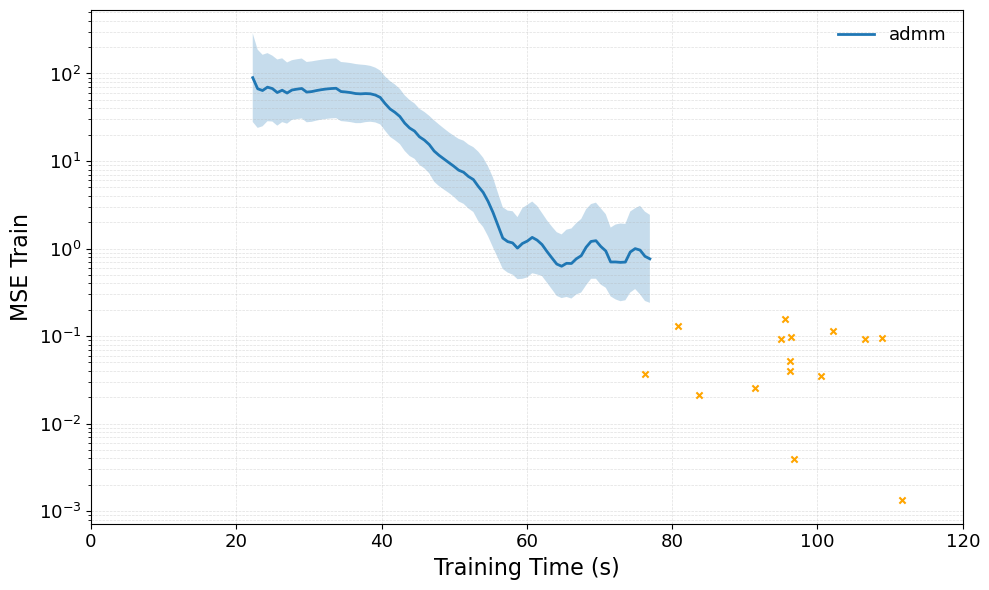

<Axes: xlabel='Training Time (s)', ylabel='MSE Train'>

In [20]:
plot_time_bands(
    {"admm":df_long},
    y_col="mse_diffrax",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    tmax_quantile=1,
    xlim =(0, 120),
    extrapolate=False,
    y_label="MSE Train",
    points_df=df_singles,
    points_size = 20
)